# Burak & Fiete (2009) CAN — Sanity Checks

Three independent checks on the CAN network


In [36]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, "/Users/jacobhornsvennevik/Documents/GitHub/CAN_Path_Integration_3D_model") 
print(os.path.abspath("..")) 
from spatial_nav.grid_cells import CAN

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})


/Users/jacobhornsvennevik/Documents/GitHub


Check 1 — Weight matrix, this is for eq. 2 and eq. 3, 


Cached W matrix loaded!
W shape    : (4096, 4096)
W min/max  : -0.0350 / 0.0000
Sparsity   : 41.6% zeros
Row sums   : mean=-16.0886  std=0.0000
Result     : OK — net inhibitory


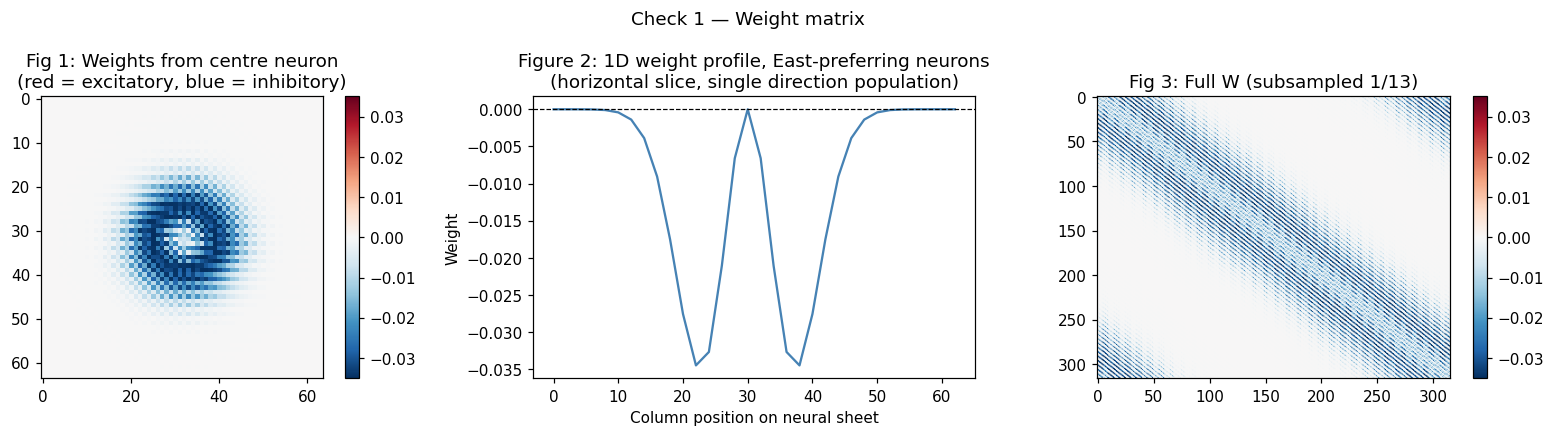

In [37]:
#Initilize tha CAN
can = CAN(periodic=True, use_real_traj=False, side_len=64)
W = can.W
N = can.num_neurons

# --- diagnostics ---
row_sums = W.sum(axis=1)
print(f"W shape    : {W.shape}")
print(f"W min/max  : {W.min():.4f} / {W.max():.4f}")
print(f"Sparsity   : {(W == 0).sum() / W.size * 100:.1f}% zeros")
print(f"Row sums   : mean={row_sums.mean():.4f}  std={row_sums.std():.4f}") #Important if not net negative bump does not stabalize
print(f"Result     : {'OK — net inhibitory' if row_sums.mean() < 0 else 'FAIL — net excitatory, check gamma_scaling'}")

# --- plot ---
#Using the center neuron
center_idx = (can.side_len // 2) * can.side_len + (can.side_len // 2)
w_center = W[center_idx].reshape(can.side_len, can.side_len)
subsample = max(1, N // 300)
sym = max(abs(W.min()), abs(W.max()))

#Seeing how strongly the center-neuron inhibit every east neuron along the middle row
mid_row = can.side_len // 2                        
east_cols = np.arange(0, can.side_len, 2)         
east_weights = w_center[mid_row, east_cols]
east_col_positions = east_cols                    

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(w_center, cmap="RdBu_r", vmin=-sym, vmax=sym)
axes[0].set_title("Fig 1: Weights from centre neuron\n(red = excitatory, blue = inhibitory)")
plt.colorbar(im0, ax=axes[0])

axes[1].plot(east_col_positions, east_weights, color="steelblue")
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[1].set_title("Figure 2: 1D weight profile, East-preferring neurons\n(horizontal slice, single direction population)")
axes[1].set_xlabel("Column position on neural sheet")
axes[1].set_ylabel("Weight")

im2 = axes[2].imshow(
    W[::subsample, ::subsample], cmap="RdBu_r",
    aspect="auto", vmin=-sym, vmax=sym
)
axes[2].set_title(f"Fig 3: Full W (subsampled 1/{subsample})")
plt.colorbar(im2, ax=axes[2])

fig.suptitle("Check 1 — Weight matrix", fontsize=12)
plt.tight_layout()
plt.show()

Check 2 - to see if the CAN self organizes after 600 * dt = 0.5 = 300ms

Cached W matrix loaded!
Peak activity  : 0.4634
Total activity : 266.8623
Active neurons : 940 / 4096
Result         : OK — bump above threshold


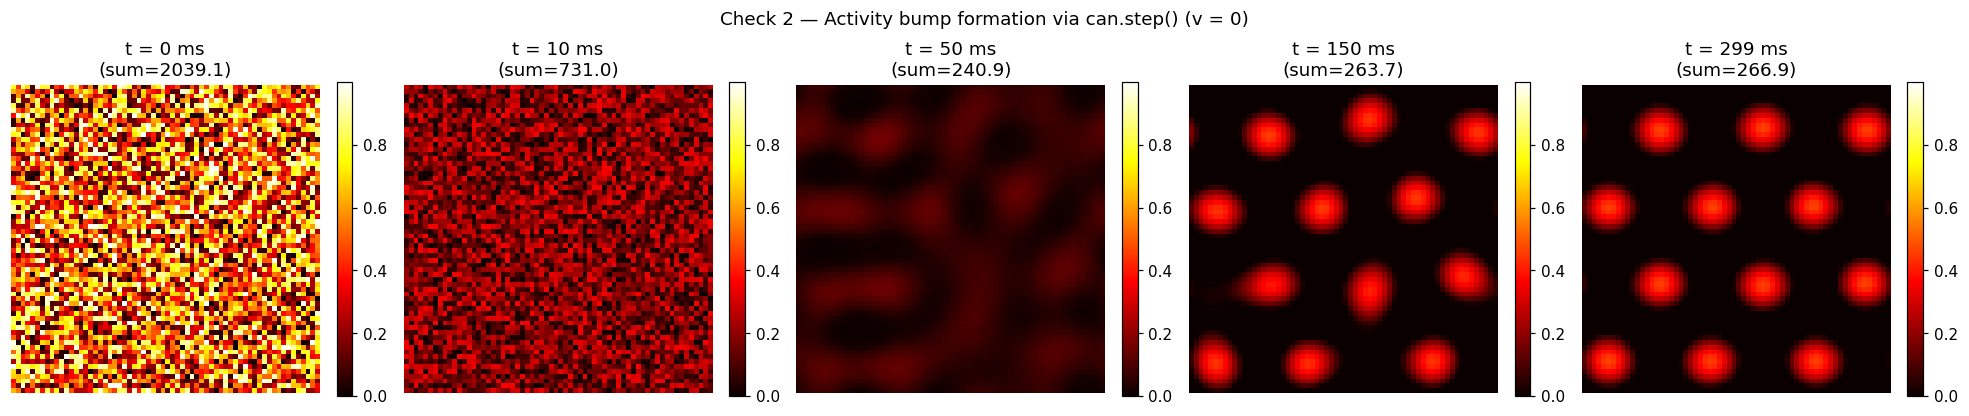

In [38]:
# --- independent state ---
can = CAN(periodic=True, use_real_traj=False, side_len=64)
N = can.num_neurons

rng = np.random.default_rng(seed=42)
s = rng.random((N,))
v_zero = np.zeros(2)

STAB_STEPS = 600                              # 600 * dt=0.5ms = 300ms
SNAP_AT = set([0, 20, 100, 300, STAB_STEPS - 1])
snapshots = {}

# --- run dynamics through can.step() ---
for i in range(STAB_STEPS):
    if i in SNAP_AT:
        snapshots[i] = s.copy()
    s = can.step(s, v_zero)

# --- diagnostics ---
final = snapshots[STAB_STEPS - 1]
print(f"Peak activity  : {final.max():.4f}")
print(f"Total activity : {final.sum():.4f}")
print(f"Active neurons : {(final > can.spike_threshold).sum()} / {N}")
print(f"Result         : {'OK — bump above threshold' if final.max() > can.spike_threshold else 'FAIL — no bump formed'}")

# --- plot ---
snap_steps = sorted(snapshots.keys())
vmax = max(snapshots[k].max() for k in snap_steps)

fig, axes = plt.subplots(1, len(snap_steps), figsize=(18, 4))
for ax, step_i in zip(axes, snap_steps):
    snap = snapshots[step_i]
    im = ax.imshow(snap.reshape(can.side_len, can.side_len), cmap="hot", vmin=0, vmax=vmax)
    ax.set_title(f"t = {int(step_i * can.dt)} ms\n(sum={snap.sum():.1f})")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle("Check 2 — Activity bump formation via can.step() (v = 0)", fontsize=12)
plt.tight_layout()
plt.show()

Very good illustration of how the bumps form after 399 ms, and it is progress all the way

After some time the activity in the CAN should stabalize this is what we are testing here.

Cached W matrix loaded!
Mean sum_i s_i : 266.9171
Std  sum_i s_i : 0.011037
CV             : 0.000041


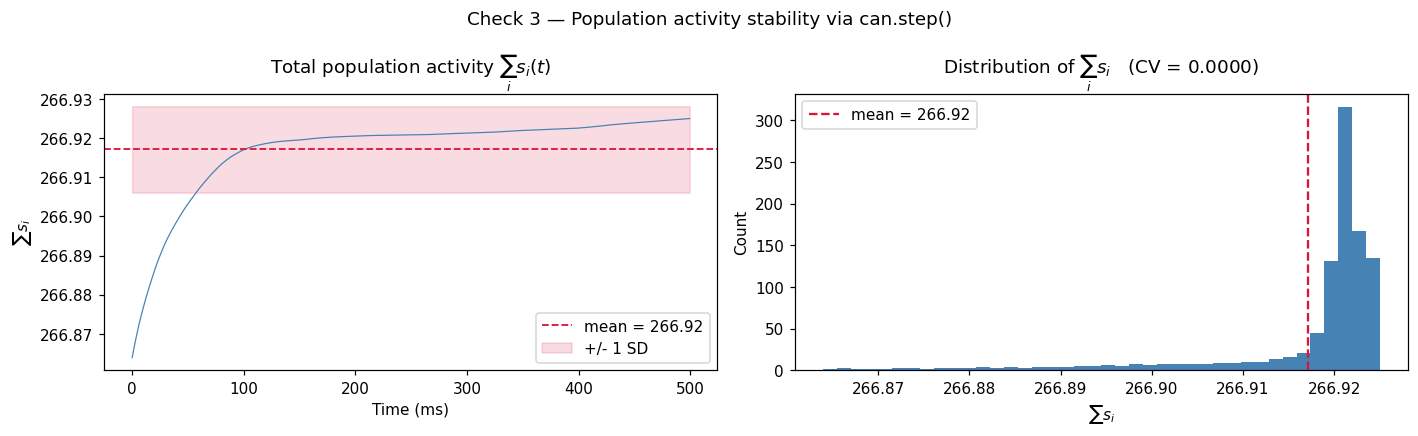

In [39]:
# --- independent state ---
can = CAN(periodic=True, use_real_traj=False, side_len=64)
N = can.num_neurons

rng = np.random.default_rng(seed=42)
s = rng.random((N,))
v_zero = np.zeros(2)

# Phase 1: stabilise 
for _ in range(600):
    s = can.step(s, v_zero)

# Phase 2: monitor, record total activity at each step via can.step()
MONITOR_STEPS = 1000                          # 1000 * dt=0.5ms = 500ms
total_activity = np.zeros(MONITOR_STEPS)

for i in range(MONITOR_STEPS):
    s = can.step(s, v_zero)
    total_activity[i] = s.sum()

# --- diagnostics ---
mean_act = total_activity.mean()
std_act = total_activity.std()
cv = std_act / mean_act if mean_act > 0 else float("inf")

status = "OK" if cv < 0.05 else ("WARN" if cv < 0.2 else "FAIL")
print(f"Mean sum_i s_i : {mean_act:.4f}")
print(f"Std  sum_i s_i : {std_act:.6f}")
print(f"CV             : {cv:.6f}")

# --- plot ---
t_axis = np.arange(MONITOR_STEPS) * can.dt    # ms

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(t_axis, total_activity, lw=0.8, color="steelblue")
axes[0].axhline(mean_act, color="crimson", lw=1.2, ls="--", label=f"mean = {mean_act:.2f}")
axes[0].fill_between(
    t_axis,
    mean_act - std_act,
    mean_act + std_act,
    alpha=0.15, color="crimson", label="+/- 1 SD"
)
axes[0].set_title(r"Total population activity $\sum_i s_i(t)$")
axes[0].set_xlabel("Time (ms)")
axes[0].set_ylabel(r"$\sum s_i$")
axes[0].legend()

axes[1].hist(total_activity, bins=40, color="steelblue", edgecolor="none")
axes[1].axvline(mean_act, color="crimson", lw=1.5, ls="--", label=f"mean = {mean_act:.2f}")
axes[1].set_title(f"Distribution of $\\sum_i s_i$   (CV = {cv:.4f})")
axes[1].set_xlabel(r"$\sum s_i$")
axes[1].set_ylabel("Count")
axes[1].legend()

fig.suptitle("Check 3 — Population activity stability via can.step()", fontsize=12)
plt.tight_layout()
plt.show()

CV = 0.000041 means extremly stable very good! But it is not completly stable it does wonder a little bit. Witch is consistent with Burak and Fiete´s paper

Now its time to check if the velocity updates are working, this will be done by measuring one bump as well as following visually!

In [40]:
# --- Check 4: bump drift under velocity input ---
can = CAN(periodic=True, use_real_traj=False, side_len=64)
N   = can.num_neurons
rng = np.random.default_rng(seed=42)
v_zero = np.zeros(2)

V_MAG = 0.0018            # alpha*|v| = 0.09, matching real-trajectory range

SNAP_TIMES_MS = [0, 50, 100, 200]
snap_steps    = [int(t / can.dt) for t in SNAP_TIMES_MS]

test_velocities = {
    'East' : np.array([ V_MAG,  0.0   ]),
    'West' : np.array([-V_MAG,  0.0   ]),
    'North': np.array([ 0.0,    V_MAG ]),
    'South': np.array([ 0.0,   -V_MAG ]),
}

direction_snapshots = {}

for direction, v_test in test_velocities.items():
    s = rng.random((N,))
    for _ in range(600):
        s = can.step(s, v_zero)

    snaps, step = [], 0
    for target in snap_steps:
        while step < target:
            s = can.step(s, v_test)
            step += 1
        snaps.append(s.copy())

    direction_snapshots[direction] = snaps

print('All snapshots collected.')


Cached W matrix loaded!
All snapshots collected.


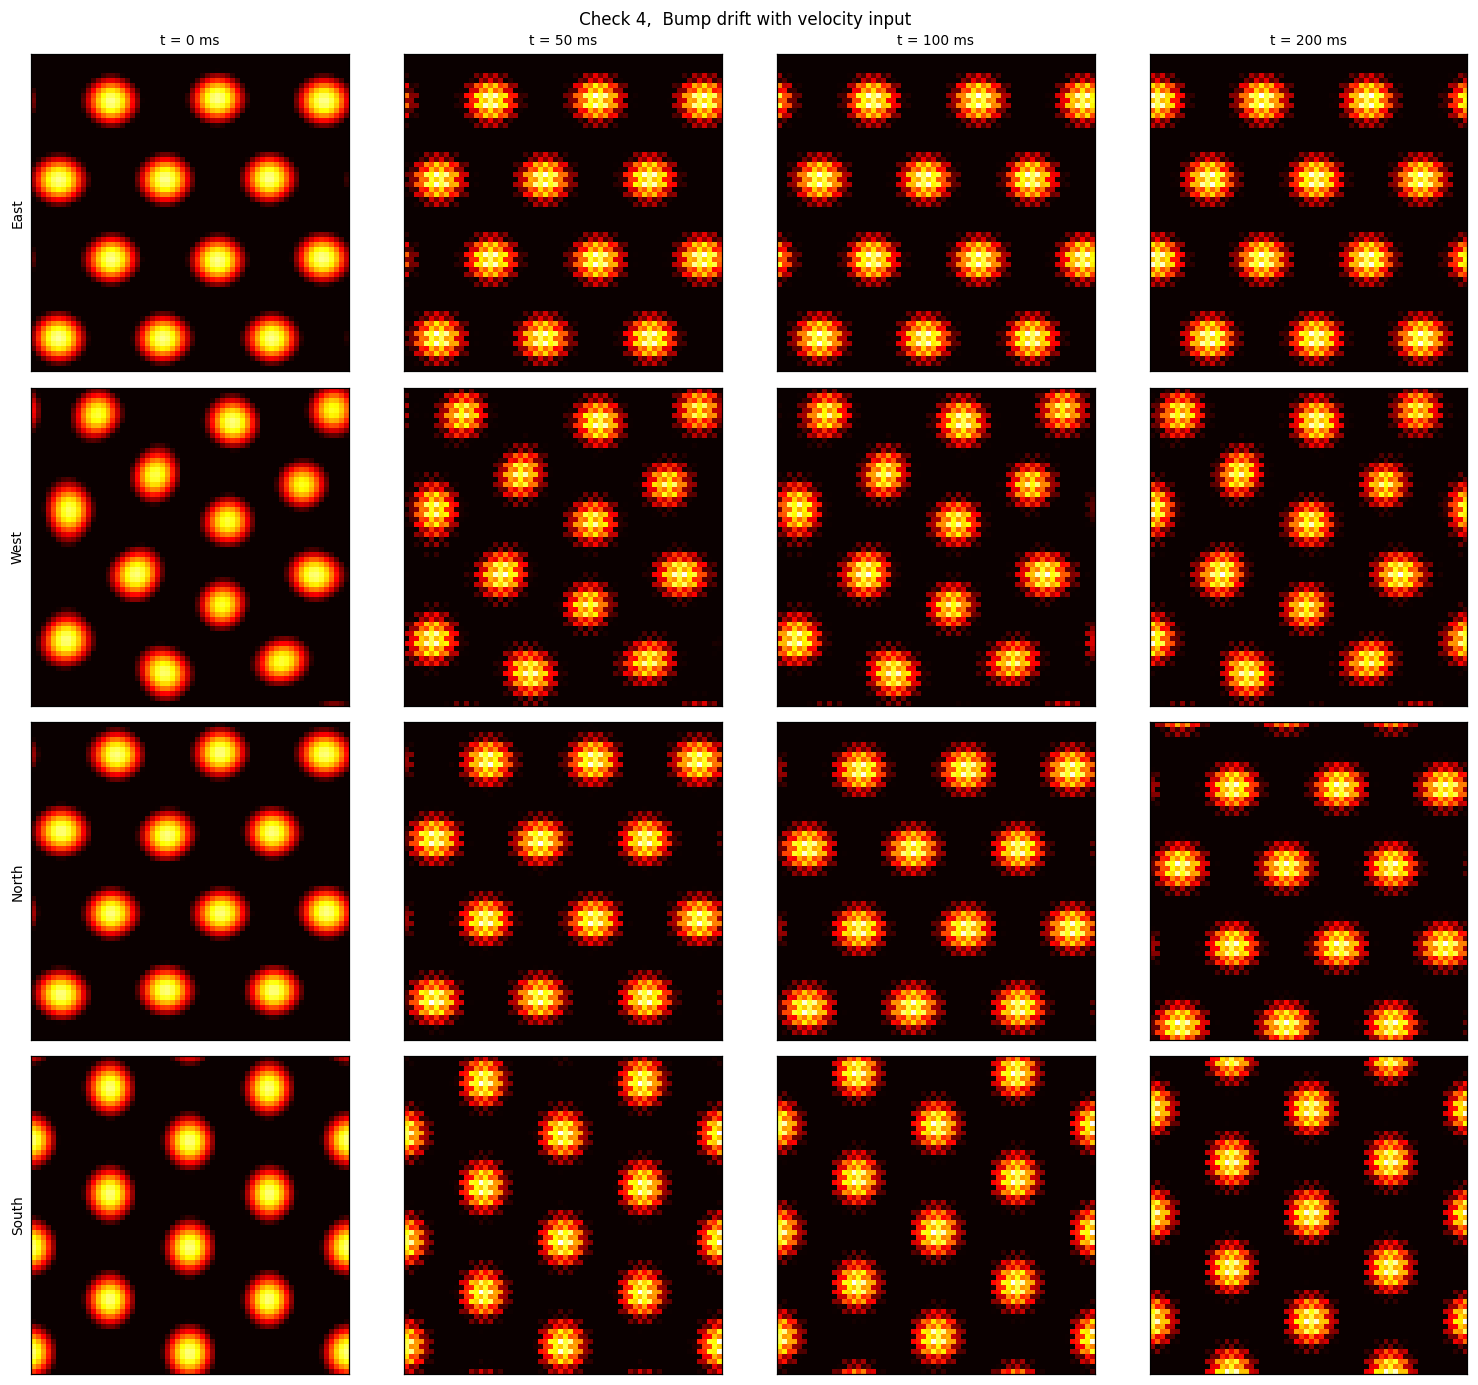

In [41]:
n_dirs  = len(direction_snapshots)
n_snaps = len(SNAP_TIMES_MS)
fig, axes = plt.subplots(n_dirs, n_snaps, figsize=(n_snaps * 3.5, n_dirs * 3.2))

for row_i, (direction, snaps) in enumerate(direction_snapshots.items()):
    vmax = max(s.max() for s in snaps)
    for col_i, (snap, t_ms) in enumerate(zip(snaps, SNAP_TIMES_MS)):
        ax = axes[row_i, col_i]
        ax.imshow(
            snap.reshape(can.side_len, can.side_len),
            cmap='hot', vmin=0, vmax=vmax, origin='upper',
        )
        ax.set_xticks([])
        ax.set_yticks([])
        if col_i == 0:
            ax.set_ylabel(direction, fontsize=9)
        if row_i == 0:
            ax.set_title(f't = {t_ms} ms', fontsize=9)

fig.suptitle('Check 4,  Bump drift with velocity input', fontsize=11)
plt.tight_layout()
plt.show()
